# Customer Churn Prediction

### Step 1: Inspect and clean dataset, convert data types

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('customer_churn_telco.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### The shape method provides information about the number of rows and columns in a DataFrame quickly and easily.

In [2]:
print('Dataset Shape:', df.shape)

Dataset Shape: (7043, 21)


> The Dataset Shape inform us about the size of the raws and columns in the dataset, delivering:
> * 7043 customers - a reasonable size for making our ML modeling (train/test split will give ~5,282 training, 1,761 test if we use 75/25 split).
>
> * 21 columns - in which includes target variable (Churn - Yes/No) and customerID, our unique identifier.
>
> __Implication:__ Enough data for logistic regression and tree-based models. CustomerID will not be used as a feature since it does not have any predictive power, it may only be used as an identifier if needed for joining later.

##### Check any missing values

In [3]:
print('Missing Values:')
print(df.isnull().sum()) # We can also use df.isna().sum()

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


> All columns currently report 0 missing values, indicating that no NaNs are present in either the numeric or categorical fields.
>
> However, the TotalCharges column is stored as an object type. As a result, some missing entries may exist as empty strings rather than true NaN values. To accurately detect and address these, we must first convert TotalCharges to a numeric type using errors='coerce', which will convert such blanks into identifiable NaNs.

##### Check Data Types

In [4]:
print('Data Types:', df.dtypes)

Data Types: customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


> Many columns are currently stored as **object** types. These primarily represent categorical features such as gender, Partner, Dependents, various service-related attributes, PaymentMethod, and Churn.
>
> The int64 columns include SeniorCitizen and tenure, which are already in numeric form.
>
> MonthlyCharges is correctly stored as a float64 type.
>
> However, TotalCharges is also stored as an object type, even though it should be numeric. This is likely due to the presence of blank string values in some rows.
>
> __Implication:__
>
> * TotalCharges needs to be converted to a float type.
>
> * All categorical columns must be encoded into numeric form (0/1 for binary variables, and one-hot or ordinal encoding for multi-class variables).
>
> * The target variable Churn should be converted into a 0/1 format for machine learning modeling.

##### Check Target Distribution

In [5]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


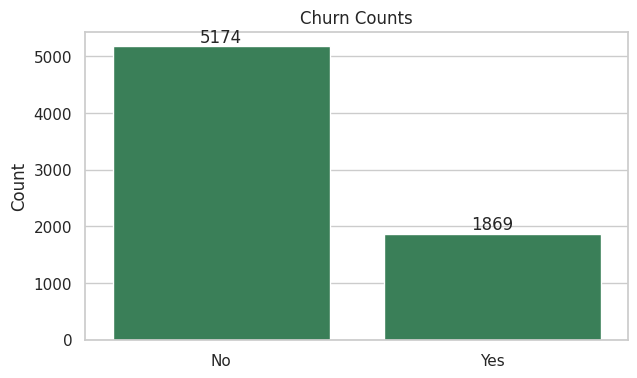

In [6]:
sns.set(style="whitegrid")

plt.figure(figsize=(7,4))

ax = sns.countplot(data=df, x='Churn', color='seagreen')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title('Churn Counts')
plt.xlabel('')
plt.ylabel('Count')

plt.show()

> About 26.5% of customers are churners, while 73.5% are non-churners. This indicates a class imbalance. We can use SMOTE to handle this imbalance.
>
> Models such as Logistic Regression or XGBoost can manage this imbalance, but evaluation metrics like precision and recall will be more informative than accuracy alone.

> __Implication:__
>
> * A stratified train/test split should be used to preserve the original class distribution.
>
> * Precision–recall curves or threshold tuning may be considered later to better handle the imbalance.

#### Conclusions

1. The dataset is generally clean, with no explicit missing values detected.

2. TotalCharges requires conversion to a numeric data type.

3. Several categorical features must be encoded (Yes/No → 1/0, multi-class → one-hot encoding).

4. The target distribution shows a moderate class imbalance, so metrics beyond accuracy should be monitored.

#### Actions

Before proceeding to data cleaning, preprocessing, and modeling, we should:

* Verify the conversion of TotalCharges to numeric. This will reveal any rows with blank values, which can then be dropped or imputed.

* Examine unique values in categorical features, particularly those with entries like "No internet service" or "No phone service," and map them consistently to 0/1.

* Determine feature types by separating numerical and categorical columns, which will guide scaling, encoding, and model selection.

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

> Now we have 11 missing values in the TotalCharges column.

In [8]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col} unique values: {df[col].unique()}")

customerID unique values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender unique values: ['Female' 'Male']
Partner unique values: ['Yes' 'No']
Dependents unique values: ['No' 'Yes']
PhoneService unique values: ['No' 'Yes']
MultipleLines unique values: ['No phone service' 'No' 'Yes']
InternetService unique values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity unique values: ['No' 'Yes' 'No internet service']
OnlineBackup unique values: ['Yes' 'No' 'No internet service']
DeviceProtection unique values: ['No' 'Yes' 'No internet service']
TechSupport unique values: ['No' 'Yes' 'No internet service']
StreamingTV unique values: ['No' 'Yes' 'No internet service']
StreamingMovies unique values: ['No' 'Yes' 'No internet service']
Contract unique values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling unique values: ['Yes' 'No']
PaymentMethod unique values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

> Based on the inspection of unique values, several actions are required.

<br />

### Observations from Unique Values

1. `customerID`

- Unique identifier → we will drop it for modeling.

<br />

2. __Binary categorical variables (Yes/No)__

`gender` (Female/Male), `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`

- These can be encoded as 0/1 (e.g., Yes=1, No=0; Female=0, Male=1).

<br />

3. __Categorical variables with “No internet service” or “No phone service”__

`MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

- The values are either Yes, No, or No internet service / No phone service

- These can be encoded carefully:

        - Map Yes → 1

        - Map No → 0

        - Map No internet service / No phone service → 0
This approach treats "No service" as equivalent to not having the feature, which is logical for modeling purposes.


<br />

4. __Multi-class categorical variables__

- `InternetService`: DSL, Fiber optic, No → One-hot encoding. Each category gets its own column, avoiding any unintended order or ranking between the categories.

- `Contract`: Month-to-month, One year, Two year → One-hot or ordinal encoding. Ordinal encoding can be useful here because the contract length has a natural order (shorter contracts may correlate with higher churn), but one-hot avoids assuming a linear relationship.

- `PaymentMethod`: One-hot encoding. This treats each payment method equally without implying any rank or priority, ensuring the model captures categorical differences accurately.


<br />

5. __Numeric variables__

- `SeniorCitizen`: already int64 → keep as numeric

- `tenure`: int64 → numeric

- `MonthlyCharges`: float64 → numeric

- `TotalCharges`: currently object → convert to numeric (already noted)

> __Actions__
>
> Dropping Missing values from `TotalCharges`

In [9]:
df= df.dropna(subset='TotalCharges')
print('New Dataset after dropping missing values:', df.shape)

New Dataset after dropping missing values: (7032, 21)


> Converting Data Types Status

In [10]:
df['TotalCharges']=df['TotalCharges'].astype(float)

> Binary columns → 0/1
>
> Columns: `gender, Partner, Dependents, PhoneService, PaperlessBilling, Churn`

In [11]:
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
service_cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

for col in binary_cols + service_cols:
    df[col] = df[col].astype(str).str.strip()

In [12]:
binary_map = {'Yes':1, 'No':0, 'Female':0, 'Male':1}

for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [13]:
service_map = {'Yes':1, 'No':0, 'No internet service':0, 'No phone service':0}

for col in service_cols:
    df[col] = df[col].map(service_map)

In [14]:
print("NaNs after mapping:", df[binary_cols + service_cols].isnull().sum())

NaNs after mapping: gender              0
Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
Churn               0
MultipleLines       0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


> Multi-class categorical columns

In [15]:
multi_cols = ['InternetService','Contract','PaymentMethod']

for col in multi_cols:
    print(f"{col} unique values: {df[col].unique()}")

InternetService unique values: ['DSL' 'Fiber optic' 'No']
Contract unique values: ['Month-to-month' 'One year' 'Two year']
PaymentMethod unique values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


The `.info()` method provides a concise summary of the DataFrame, showing the number of entries, column names, data types, and non-null counts. This helps quickly identify which columns are numeric vs. object type and whether there are any missing values.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   int64  
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   int64  
 14  StreamingMovies   7032 non-null   int64  
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  
 17  

> We now have clean data, types are correct, no missing values, and target is ready for modeling.

In [17]:
df = df.drop("customerID", axis=1)

### Feature Engineering & Preprocessing

__Objective:__ Prepare the dataset for machine learning by encoding categorical variables, scaling numeric features, creating a clean feature matrix, and splitting the data into training and test sets for modeling.

##### One-Hot Encoding of Multi-Class Categorical Features

> `InternetService, Contract, PaymentMethod`


> These features are multi-class categorical variables. Since Logistic Regression requires numeric input, we convert each category into a separate binary column (0/1) using one-hot encoding.
>
> `drop_first=True` avoids multicollinearity

In [18]:
multi_cols=['InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns = multi_cols, drop_first=True)
print('New columns after one-hot encoding: ', df.columns.tolist())

New columns after one-hot encoding:  ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


##### Feature Separation: X (features) and y (target)

> Churn (0 = No, 1 = Yes)

In [19]:
# Target variable (y)
y = df['Churn']

# Features (predictors) (x)
X = df.drop(columns=['Churn'])

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7032, 23)
Target Shape: (7032,)


##### Scaling Numeric Features (for Logistic Regression)

> `SeniorCitizen, tenure, MonthlyCharges, TotalCharges`
>
> Logistic Regression is sensitive to the scale of features.
> Scaling ensures that coefficients are comparable and that gradient descent converges efficiently.
>
> For tree-based models like XGBoost, feature scaling is not necessary, as these models are scale-invariant.

In [20]:
from sklearn.preprocessing import StandardScaler

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print(X[num_cols].head())

   SeniorCitizen    tenure  MonthlyCharges  TotalCharges
0      -0.440327 -1.280248       -1.161694     -0.994194
1      -0.440327  0.064303       -0.260878     -0.173740
2      -0.440327 -1.239504       -0.363923     -0.959649
3      -0.440327  0.512486       -0.747850     -0.195248
4      -0.440327 -1.239504        0.196178     -0.940457


##### Train-Test Split

The startegy that we will use here is:

> 75% training, 25% testing

> **Stratified split** to maintain churn proportion in both sets

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42, stratify = y)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (5274, 23)
Test set shape: (1758, 23)


##### Interaction & Derived Features

__Average Monthly Spend__

In [22]:
# Avoid division by zero
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'].replace(0, 1))

__High-Risk Customer Flags__

In [23]:
df['HighMonthlyCharges'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

df['ShortTenure'] = (df['tenure'] < 6).astype(int)

__Correlation & Multicollinearity Check__

Linear models, such as Logistic Regression, can be negatively affected by highly correlated features (multicollinearity).
Tree-based models, like XGBoost, are not impacted by multicollinearity, but it’s still good practice to inspect correlations.

In this case, we retain all features because both tree models and scaled logistic regression can handle them. In stricter settings, one of the correlated columns might be dropped to simplify the model.

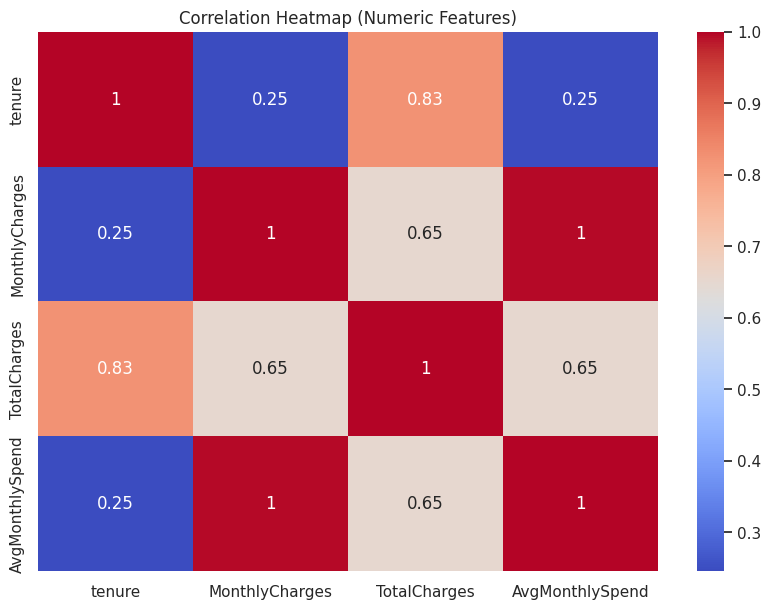

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

__Outlier Detection (Numeric Features)__

Numeric anomalies can destabilize logistic regression and distort scaling.

Check with simple IQR method:

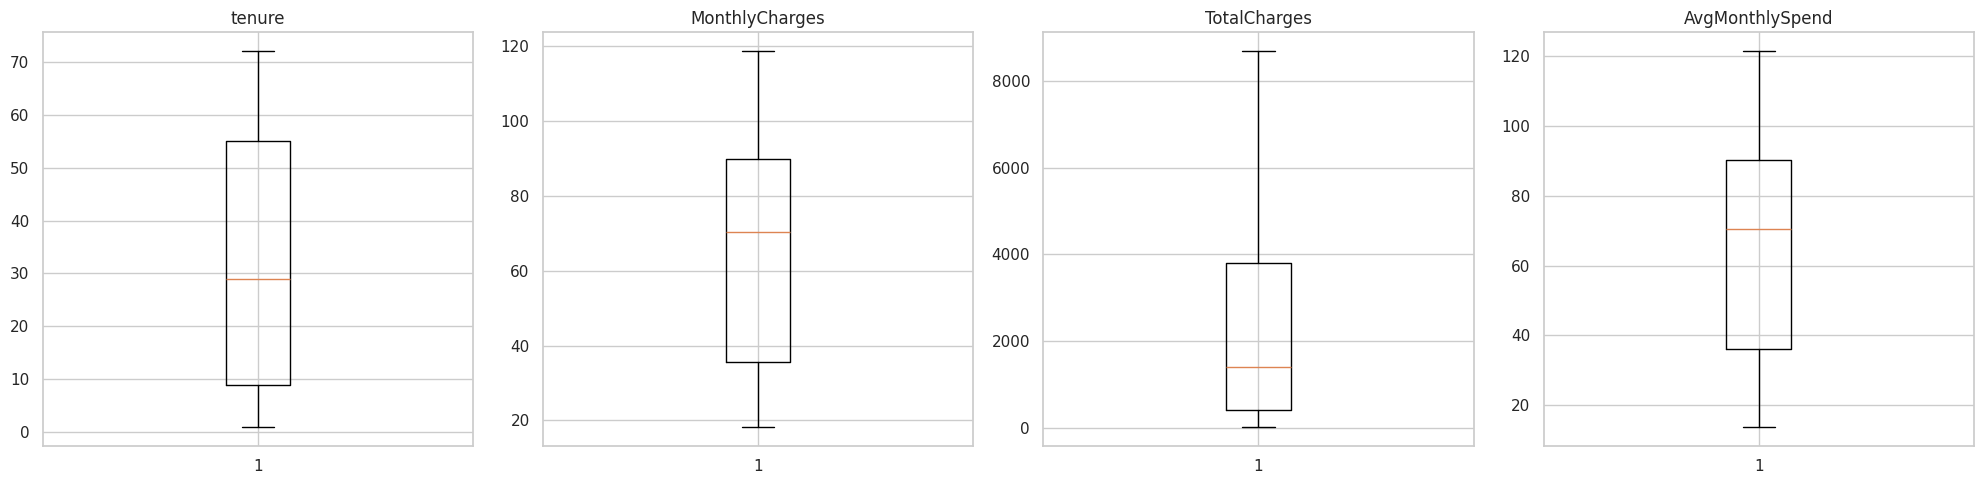

In [25]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [26]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers
AvgMonthlySpend: 0 outliers


Using boxplots and the IQR method, we confirm that there are no significant outliers in the dataset.

### Model Building & Evaluation

#### Logistic Regression (Baseline Model)
<br />

##### Prepare Features (X) and Target (y)

We first split the dataset into:

* X = all features

* y = Churn (0 = No, 1 = Yes)

In [27]:
X = df.drop("Churn", axis = 1)
y = df["Churn"]

__Train/Test Split (80/20)__

We split data while maintaining class balance using stratify=y.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)


__Feature Scaling__

Logistic Regression requires scaled numeric features for:

* stable coefficient estimation

* faster convergence

* avoiding numerical instability

We use StandardScaler, applied only to training data

In [29]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

__Train Logistic Regression__

Regularization is important, so we use `liblinear` solver.

In [30]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter = 100, solver = 'liblinear')
log_model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

__Predictions__

In [31]:
y_pred = log_model.predict(X_test)
y_prod = log_model.predict_proba(X_test)[:,1]

__Model Evaluation__

Accuracy | Precision | Recall | F1

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7953091684434968
Precision: 0.6352201257861635
Recall: 0.5401069518716578
F1 Score: 0.5838150289017341


__Confusion Matrix__

This is essential for churn analysis, because false negatives (predicting non-churn when customer actually churns) are costly.

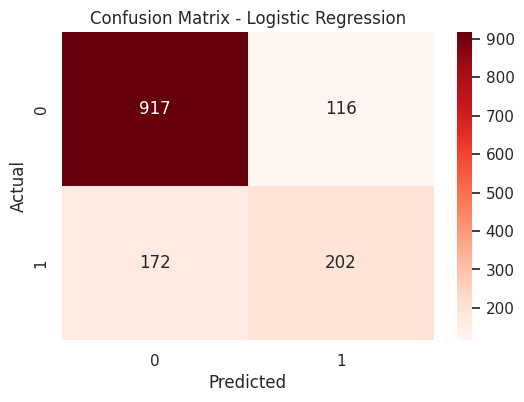

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap ='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

> * False Negatives (172) → churners predicted as non-churn → primary risk.
>
> * False Positives (116) → predicted churn but actually stayed → less costly, may trigger marketing unnecessarily.

__Classification Report__

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



>__Accuracy__:
> * 80% of all predictions are correct.
> * Accuracy alone can be misleading because the dataset is imbalanced (~27% churn rate).
>
>__Precision and Recall__:
> * Class 0 (No churn)
>
>    - High precision & recall → most non-churning customers are correctly identified.

> * Class 1 (Churn)
>
>    - Precision 0.64 → of all customers predicted to churn, 64% actually churned
>    - Recall 0.54 → model only captures 54% of actual churners
>    - F1-score 0.58 → harmonic mean of precision & recall; moderate performance

Missing churners (false negatives) is costly in business - customers leave without retention efforts.

### Summary

* Logistic Regression gives a good baseline (~80% accuracy).

* Weakness: detecting churners (class 1) → recall 0.54 is moderate.

* Next Steps:

     - Consider XGBoost, which handles imbalanced data better and often improves recall.

     - Consider SMOTE or class weighting to improve recall for churners.

In [35]:
# === Hyperparameter tuning ===
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(estimator=LogisticRegression(solver='liblinear', max_iter=100),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

# Store the tuned model in a new variable
tuned_log_model = grid_search.best_estimator_

# === Compare baseline vs tuned ===
baseline_acc = log_model.score(X_test, y_test)
tuned_acc = tuned_log_model.score(X_test, y_test)

print("Baseline Accuracy:", baseline_acc)
print("Tuned Accuracy:", tuned_acc)
print("Best Hyperparameters:", grid_search.best_params_)

Baseline Accuracy: 0.7953091684434968
Tuned Accuracy: 0.7924662402274343
Best Hyperparameters: {'C': 0.1, 'penalty': 'l1'}


In [36]:
# Make predictions
y_pred_baseline = log_model.predict(X_test)
y_pred_tuned = tuned_log_model.predict(X_test)

# Metrics for baseline
baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline)
baseline_rec = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

# Metrics for tuned model
tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

# Display comparison
print("=== Baseline Model Metrics ===")
print(f"Accuracy: {baseline_acc:.4f}, Precision: {baseline_prec:.4f}, Recall: {baseline_rec:.4f}, F1: {baseline_f1:.4f}\n")

print("=== Tuned Model Metrics ===")
print(f"Accuracy: {tuned_acc:.4f}, Precision: {tuned_prec:.4f}, Recall: {tuned_rec:.4f}, F1: {tuned_f1:.4f}")

=== Baseline Model Metrics ===
Accuracy: 0.7953, Precision: 0.6352, Recall: 0.5401, F1: 0.5838

=== Tuned Model Metrics ===
Accuracy: 0.7925, Precision: 0.6367, Recall: 0.5107, F1: 0.5668


__Train Decision Trees__

Hyperparameter tuning is possible, but for now we can use a simple Decision Tree using `gini` as the splitting criterion.

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

__Predictions__

In [38]:
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

__Model Evaluation__

Accuracy | Precision | Recall | F1

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7221037668798863
Precision: 0.47780678851174935
Recall: 0.4893048128342246
F1 Score: 0.48348745046235136


__Confusion Matrix__

This is essential for churn analysis, because false negatives (predicting non-churn when customer actually churns) are costly.

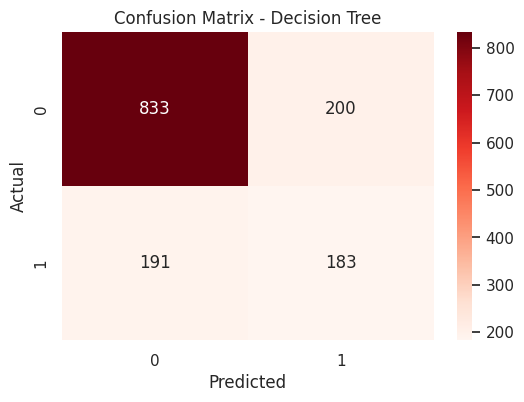

In [40]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

__Classification Report__

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.48      0.49      0.48       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.72      0.72      0.72      1407



In [42]:
# === Hyperparameter tuning ===
param_grid = {
    'max_depth': [None, 3, 5, 7, 10],      # Max depth of the tree
    'min_samples_split': [2, 5, 10],       # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],         # Minimum samples at a leaf node
    'criterion': ['gini', 'entropy']       # Splitting criterion
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

# Store tuned model
tuned_dt_model = grid_search.best_estimator_

# === Predictions ===
y_pred_baseline = dt_model.predict(X_test)
y_pred_tuned = tuned_dt_model.predict(X_test)

# === Metrics comparison ===
metrics = {
    'Model': ['Baseline', 'Tuned'],
    'Accuracy': [accuracy_score(y_test, y_pred_baseline), accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, y_pred_baseline), precision_score(y_test, y_pred_tuned)],
    'Recall': [recall_score(y_test, y_pred_baseline), recall_score(y_test, y_pred_tuned)],
    'F1': [f1_score(y_test, y_pred_baseline), f1_score(y_test, y_pred_tuned)]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Best hyperparameters
print("\nBest Hyperparameters for Tuned Decision Tree:", grid_search.best_params_)

      Model  Accuracy  Precision    Recall        F1
0  Baseline  0.722104   0.477807  0.489305  0.483487
1     Tuned  0.784648   0.656388  0.398396  0.495840

Best Hyperparameters for Tuned Decision Tree: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


__Train Random Forest__

Accuracy: 0.7839374555792467
Precision: 0.6182432432432432
Recall: 0.4893048128342246
F1 Score: 0.5462686567164179


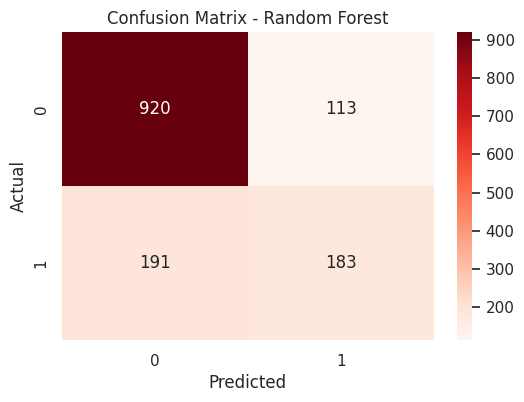

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407



In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

print(classification_report(y_test, y_pred))

=== Baseline Random Forest Metrics ===
{'Accuracy': 0.7839374555792467, 'Precision': 0.6182432432432432, 'Recall': 0.4893048128342246, 'F1': 0.5462686567164179}

=== Baseline vs Tuned Random Forest ===
          Accuracy  Precision    Recall        F1
Baseline  0.783937   0.618243  0.489305  0.546269
Tuned     0.794598   0.647059  0.500000  0.564103


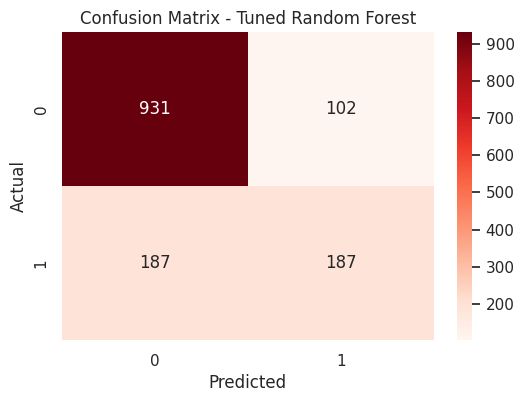


Classification Report - Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.79      1407

Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 117}


In [44]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# === Baseline Random Forest ===
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_baseline = rf_model.predict(X_test)

# Baseline metrics
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline),
    'Recall': recall_score(y_test, y_pred_baseline),
    'F1': f1_score(y_test, y_pred_baseline)
}

print("=== Baseline Random Forest Metrics ===")
print(baseline_metrics)

# === Randomized Hyperparameter Tuning ===
param_dist = {
    'n_estimators': randint(100, 300),          # Number of trees
    'max_depth': [None, 5, 10, 20],             # Max depth of tree
    'min_samples_split': randint(2, 11),        # Minimum samples to split
    'min_samples_leaf': randint(1, 5),          # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None]      # Features considered at each split
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

# Tuned model
tuned_rf_model = random_search.best_estimator_
y_pred_tuned = tuned_rf_model.predict(X_test)

# Tuned metrics
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1': f1_score(y_test, y_pred_tuned)
}

# === Compare baseline vs tuned ===
metrics_df = pd.DataFrame([baseline_metrics, tuned_metrics], index=['Baseline', 'Tuned'])
print("\n=== Baseline vs Tuned Random Forest ===")
print(metrics_df)

# === Confusion Matrix for Tuned Model ===
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

# Classification report
print("\nClassification Report - Tuned Random Forest:")
print(classification_report(y_test, y_pred_tuned))

# Best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)

### XGBoost for Churn Prediction

Build a more powerful tree-based model to improve churn prediction, especially recall for class 1 (churners).

__Install & Import XGBoost__

In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report

__Initialize the Model__

In [46]:
# Compute imbalance ratio
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

In [47]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,   # balances positive class
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

__Train the Model__

In [48]:
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:13:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

__Make Predictions__

In [49]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

__Evaluate the Model__

Confusion Matrix

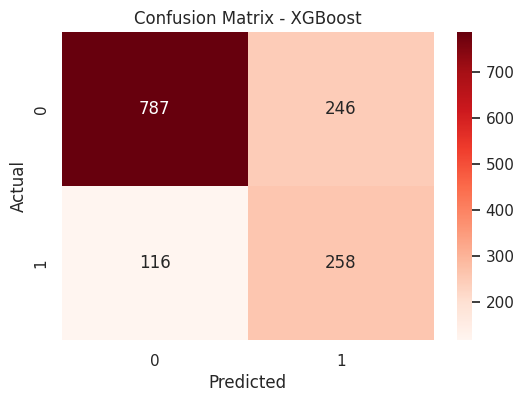

In [50]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize = (6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

* __TP (True Positives)__: Churners correctly predicted as churn

* __TN (True Negatives)__: Non-churners correctly predicted as non-churn

* __FP (False Positives)__: Non-churners incorrectly predicted as churn

* __FN (False Negatives)__: Churners incorrectly predicted as non-churn

__Classification Report__

In [51]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1033
           1       0.51      0.69      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



> __Accuracy__:
> 0.74
>
> __Precision & Recall__:
>
> * Churn (1):
>   - Precision  gives a moderate precision of 51% predicted as churns from the total actually churned.
>   - Recall model identifies 69% of actual churners.
>   - F1-score: 0.59 → moderate, reflects decent recall with lower precision.
>
> * Churn (0):
>   - Has better precision, recall, f1-score performance.

__Feature Importance__

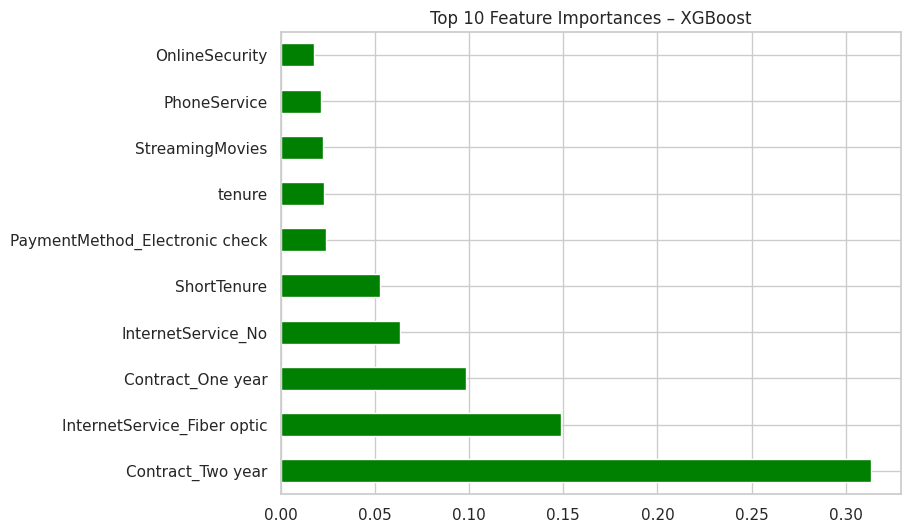

In [52]:
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,6), color='green')
plt.title("Top 10 Feature Importances – XGBoost")
plt.show()

#### Summary

* Accuracy: Overall correctness (less important for imbalanced data).

* Precision (churn): How many predicted churners actually churn.

* Recall (churn): How many actual churners are caught - key metric for retention.

* F1-score: Balances precision and recall → single-number measure of churn detection effectiveness.

### Business Recommendations & Insights

After analyzing customer data and building predictive models for churn, several actionable insights have emerged to help reduce customer attrition and improve retention strategies.

__1. Identify High-Risk Customers__

Our models, particularly XGBoost, effectively predict customers with a high probability of churn. The primary drivers of churn are month-to-month contracts, shorter tenure, higher monthly charges, and lack of key services such as online security or tech support. By focusing retention efforts on these high-risk customers, the company can proactively prevent attrition and prioritize resources where they will have the greatest impact.

__2. Targeted Retention Campaigns__

For customers identified as high-risk, targeted campaigns should be implemented. Examples include offering discounts, loyalty rewards, or service bundles. Specifically, new customers (with tenure less than one year) and those on month-to-month plans are most vulnerable and should receive personalized retention offers. Bundling services like tech support or online security can also increase customer stickiness and reduce churn.

__3. Service and Pricing Improvements__

Churn analysis indicates that customers with fiber optic internet and higher monthly charges are more likely to leave. Investigating service quality issues and offering flexible pricing options may reduce dissatisfaction. Introducing tiered plans, promotions, or discounts for high-value customers can further mitigate churn risk.

__4. Monitoring and Continuous Improvement__

Retention efforts should be continuously monitored for effectiveness. Metrics such as campaign ROI, changes in churn rates, and customer feedback should inform adjustments to the strategy. Additionally, retraining predictive models periodically with fresh data ensures that the company remains responsive to evolving customer behavior.

__Conclusion__

By leveraging predictive analytics and focusing on the key drivers of churn, the company can implement data-driven strategies to retain customers more effectively. The combination of targeted retention campaigns, service improvements, and ongoing monitoring provides a structured approach to minimizing churn and maximizing long-term customer value.

### Key Metrics, Confusion Matrix, Top Features

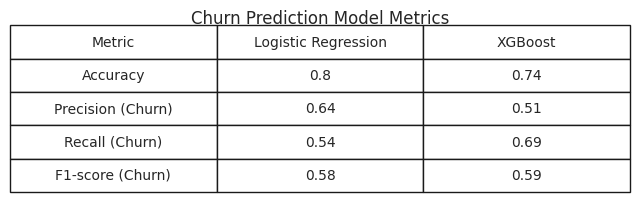

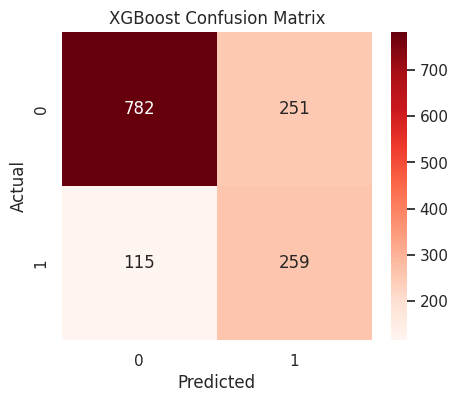

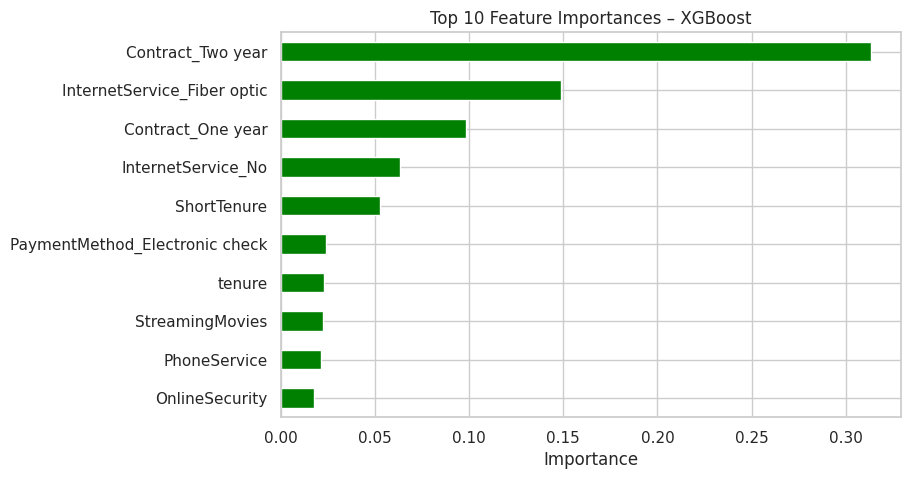

In [53]:
# Key Metrics Table
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-score (Churn)'],
    'Logistic Regression': [0.80, 0.64, 0.54, 0.58],
    'XGBoost': [0.74, 0.51, 0.69, 0.59]
})

# Plot key metrics table
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
tbl = ax.table(cellText=metrics.values, colLabels=metrics.columns, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2)
plt.title("Churn Prediction Model Metrics", fontsize=12)
plt.show()

# Confusion Matrix for XGBoost
cm = [[782, 251],
      [115, 259]]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

# Top 10 Feature Importances from XGBoost
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,5), color='green')
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances – XGBoost")
plt.gca().invert_yaxis()
plt.show()